# Guidance for training a model with your own data

## 1. Import the necessary packages

In [1]:
import argparse
import os
import random

import numpy as np
import pandas as pd
import torch

from exp.exp_custom import Exp_Custom

## 2. Define the hyperparameters

In [2]:
# fix seed for reproducibility
fix_seed = 2021
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)
torch.set_num_threads(6)

# basic config
config = {
    # dataset settings
    'root_path': '../data/processed/',
    'data_path': 'softs_cleaned_data.csv',
    'data': 'APPLEAABACLOSE',
    'features': 'M',
    'freq': 'h',
    'seq_len': 96,
    'pred_len': 96,
    # model settings
    'model': 'SOFTS',
    'checkpoints': './checkpoints/',
    'd_model': 128,
    'd_core': 64,
    'd_ff': 128,
    'e_layers': 2,
    'learning_rate': 0.0003,
    'lradj': 'cosine',
    'train_epochs': 50,
    'patience': 3,
    'batch_size': 16,
    'dropout': 0.0,
    'activation': 'gelu',
    'use_norm': True,
    # system settings
    'num_workers': 0,
    'use_gpu': True,
    'gpu': '0',
    'save_model': True,
}

parser = argparse.ArgumentParser(description='SOFTS')
args = parser.parse_args([])
args.__dict__.update(config)
args.use_gpu = True if torch.cuda.is_available() and args.use_gpu else False

print('Args in experiment:')
print(args)

Args in experiment:
Namespace(root_path='../data/processed/', data_path='softs_cleaned_data.csv', data='APPLEAABACLOSE', features='M', freq='h', seq_len=96, pred_len=96, model='SOFTS', checkpoints='./checkpoints/', d_model=128, d_core=64, d_ff=128, e_layers=2, learning_rate=0.0003, lradj='cosine', train_epochs=50, patience=3, batch_size=16, dropout=0.0, activation='gelu', use_norm=True, num_workers=0, use_gpu=True, gpu='0', save_model=True)


## 3. Prepare the dataset
Organize your data in the following format:
- The dataset should be a csv file.
- If there is a time feature, the first column contains timestamps in the format 'YYYY-MM-DD HH:MM:SS'. If there's no time feature, the dataset starts directly with the features.
- If the parameter `features` is 'M', the following columns are both the features and the targets. If `features` is 'MS', the following columns are the features, and the last column is the target.

In [3]:
# load data
data = pd.read_csv(os.path.join(args.root_path, args.data_path))
print(data.head())

# split data
#train_data = data.iloc[: 12 * 30 * 24 * 4]
#vali_data = data.iloc[12 * 30 * 24 * 4 - args.seq_len: 12 * 30 * 24 * 4 + 4 * 30 * 24 * 4]
#test_data = data.iloc[12 * 30 * 24 * 4 + 4 * 30 * 24 * 4 - args.seq_len: 12 * 30 * 24 * 4 + 8 * 30 * 24 * 4]

#split stock data
# total length
N = len(data)                   # 3019

# split points
train_end = int(N * 0.70)       # 70% train
val_end   = int(N * 0.85)       # next 15% val

#slice
train_data = data.iloc[: train_end]

vali_data  = data.iloc[train_end - args.seq_len : val_end]

test_data  = data.iloc[val_end - args.seq_len : ]

# optional: scale data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
if 'Date' in train_data.columns:
    scaler.fit(train_data.iloc[:, 1:])
    train_data.iloc[:, 1:] = scaler.transform(train_data.iloc[:, 1:])
    vali_data.iloc[:, 1:] = scaler.transform(vali_data.iloc[:, 1:])
    test_data.iloc[:, 1:] = scaler.transform(test_data.iloc[:, 1:])
else:
    scaler.fit(train_data.iloc[:, :])
    train_data.iloc[:, :] = scaler.transform(train_data.iloc[:, :])
    vali_data.iloc[:, :] = scaler.transform(vali_data.iloc[:, :])
    test_data.iloc[:, :] = scaler.transform(test_data.iloc[:, :])

                  Date   AABA   AAPL   AMZN    AXP     BA    CAT   CSCO  \
0  2006-01-03 16:00:00  40.91  10.68  47.58  52.58  70.44  57.80  17.45   
1  2006-01-04 16:00:00  40.97  10.71  47.25  51.95  71.17  59.27  17.85   
2  2006-01-05 16:00:00  41.53  10.63  47.65  52.50  70.33  59.27  18.35   
3  2006-01-06 16:00:00  43.21  10.90  47.87  52.68  69.35  60.45  18.77   
4  2006-01-09 16:00:00  43.42  10.86  47.08  53.99  68.77  61.55  19.06   

     CVX    DIS  ...    NKE    PFE     PG      SP500    TRV    UNH    UTX  \
0  59.08  24.40  ...  10.74  23.78  58.78  88.224953  45.99  61.73  56.53   
1  58.91  23.99  ...  10.69  24.55  58.89  88.642776  46.50  61.88  56.19   
2  58.19  24.41  ...  10.76  24.58  58.70  88.698463  46.95  61.69  55.98   
3  59.25  24.74  ...  10.72  24.85  58.64  89.436554  47.21  62.90  56.16   
4  58.95  25.00  ...  10.88  24.85  59.08  89.666359  47.23  61.40  56.80   

      VZ    WMT    XOM  
0  30.38  46.23  58.47  
1  31.27  46.32  58.57  
2  31.63  4

In [4]:
# 1. First, let's examine the data more closely to check for extreme values:
def inspect_data_statistics(data, name="data"):
    """Detailed statistics to find potential numerical issues."""
    print(f"\n--- Detailed Statistics for {name} ---")
    
    # Remove any date column for the analysis
    numeric_data = data.select_dtypes(include=[np.number]) if isinstance(data, pd.DataFrame) else data
    
    # Basic statistics
    print(f"Min values: {numeric_data.min().min()}")
    print(f"Max values: {numeric_data.max().max()}")
    
    # Check for zeros that might cause division issues
    zero_count = (numeric_data == 0).sum().sum()
    print(f"Zero values: {zero_count} ({zero_count/numeric_data.size:.6%} of all elements)")
    
    # Check for very small values that might cause numerical instability
    small_val_count = (np.abs(numeric_data) < 1e-10).sum().sum()
    print(f"Very small values (< 1e-10): {small_val_count} ({small_val_count/numeric_data.size:.6%} of all elements)")
    
    # Check for very large values
    large_val_count = (np.abs(numeric_data) > 1e10).sum().sum()
    print(f"Very large values (> 1e10): {large_val_count} ({large_val_count/numeric_data.size:.6%} of all elements)")
    
    # Look at the distribution
    if isinstance(numeric_data, pd.DataFrame):
        for col in numeric_data.columns:
            q1 = numeric_data[col].quantile(0.25)
            median = numeric_data[col].median()
            q3 = numeric_data[col].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            outliers = ((numeric_data[col] < lower_bound) | (numeric_data[col] > upper_bound)).sum()
            if outliers > 0:
                print(f"Column {col} has {outliers} outliers ({outliers/len(numeric_data):.2%})")
                print(f"  Range: [{numeric_data[col].min()}, {numeric_data[col].max()}]")
    
    print("---------------------------------------")

# Check your data
inspect_data_statistics(train_data, "train_data")
inspect_data_statistics(vali_data, "vali_data")
inspect_data_statistics(test_data, "test_data")


--- Detailed Statistics for train_data ---
Min values: -8.208633301726046
Max values: 3.1033990518162646
Zero values: 0 (0.000000% of all elements)
Very small values (< 1e-10): 0 (0.000000% of all elements)
Very large values (> 1e10): 0 (0.000000% of all elements)
Column AXP has 150 outliers (7.10%)
  Range: [-3.0045943770870593, 2.3850915761722518]
Column BA has 168 outliers (7.95%)
  Range: [-3.3647493872772984, 2.829390708877797]
Column CAT has 101 outliers (4.78%)
  Range: [-3.8084261328867504, 2.0671965747237087]
Column CSCO has 97 outliers (4.59%)
  Range: [-5.570809263081805, 3.1033990518162646]
Column CVX has 96 outliers (4.54%)
  Range: [-4.4683662565485776, 1.9051643617268275]
Column DIS has 285 outliers (13.48%)
  Range: [-2.544532268432973, 2.523671377507307]
Column GOOGL has 226 outliers (10.69%)
  Range: [-2.944346834766966, 2.7894970201898452]
Column GS has 96 outliers (4.54%)
  Range: [-4.264275825045388, 2.6509292830527778]
Column HD has 355 outliers (16.79%)
  Range:

In [5]:
# Add constraints to the SOFTS model to prevent negative probabilities
def add_probability_safeguards(model):
    """Patch model forward passes to ensure probability outputs are valid."""
    
    # Store the original forward method
    original_forward = model.forward
    
    # Define a new forward method with safety checks
    def safe_forward(*args, **kwargs):
        # Get output from original forward method
        output = original_forward(*args, **kwargs)
        
        # If output is tensor (not tuple/list), apply safety directly
        if isinstance(output, torch.Tensor):
            # For probability-like outputs, ensure they're in valid range
            if output.requires_grad:
                # Use clamp or other operations that maintain gradients
                # This is a generic fix - might need customization for specific models
                return torch.clamp(output, min=1e-7, max=1e7) 
            else:
                return output
        
        # If output is tuple/list, process each tensor
        if isinstance(output, (tuple, list)):
            safe_outputs = []
            for tensor in output:
                if isinstance(tensor, torch.Tensor) and tensor.requires_grad:
                    # Apply safety constraint
                    safe_tensor = torch.clamp(tensor, min=1e-7, max=1e7)
                    safe_outputs.append(safe_tensor)
                else:
                    safe_outputs.append(tensor)
                    
            # Return in same format
            if isinstance(output, tuple):
                return tuple(safe_outputs)
            return safe_outputs
            
        # Default case - just return original output
        return output
    
    # Replace the forward method
    model.forward = safe_forward
    
    return model


In [8]:
import types

def normalize_data(data):
    """
    Normalize each column to have zero mean and unit variance
    """
    # Store the Date column if it exists
    date_col = data['Date'].copy() if 'Date' in data.columns else None
    
    # Get numeric columns
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    
    # Normalize each column
    scaler = StandardScaler()
    data_normalized = data.copy()
    data_normalized[numeric_cols] = scaler.fit_transform(data[numeric_cols])
    
    # Add back the Date column if it existed
    if date_col is not None:
        data_normalized['Date'] = date_col
        
    return data_normalized, scaler

# Normalize the data
train_data_normalized, train_scaler = normalize_data(train_data)
vali_data_normalized, _ = normalize_data(vali_data)
test_data_normalized, _ = normalize_data(test_data)

# Make copies without the Date column
train_data_no_date = train_data_normalized.drop('Date', axis=1) if 'Date' in train_data_normalized.columns else train_data_normalized
vali_data_no_date = vali_data_normalized.drop('Date', axis=1) if 'Date' in vali_data_normalized.columns else vali_data_normalized
test_data_no_date = test_data_normalized.drop('Date', axis=1) if 'Date' in test_data_normalized.columns else test_data_normalized

# Add numerical stability to the STAR module
def add_probability_safeguards(model):
    """
    Add safeguards to prevent numerical instability in the STAR module
    """
    def safe_softmax(self, x, dim=1):
        # Clip values to prevent extreme numbers
        x = torch.clamp(x, -100, 100)
        # Subtract max for numerical stability
        x_max = torch.max(x, dim=dim, keepdim=True)[0]
        exp_x = torch.exp(x - x_max)
        return exp_x / torch.sum(exp_x, dim=dim, keepdim=True)
    
    for module in model.modules():
        if hasattr(module, 'forward') and 'STAR' in module.__class__.__name__:
            module.safe_softmax = types.MethodType(safe_softmax, module)
            
            # Modify the forward method to use safe_softmax
            original_forward = module.forward
            def safe_forward(self, input, *args, **kwargs):
                batch_size, channels, d_series = input.shape
                combined_mean = F.gelu(self.gen1(input))
                combined_mean = self.gen2(combined_mean)
                
                if self.training:
                    ratio = self.safe_softmax(combined_mean, dim=1)
                    ratio = ratio.permute(0, 2, 1)
                    ratio = ratio.reshape(-1, channels)
                    # Add small epsilon to ensure all probabilities are positive
                    ratio = ratio + 1e-10
                    ratio = ratio / ratio.sum(dim=1, keepdim=True)
                    indices = torch.multinomial(ratio, 1)
                    indices = indices.view(batch_size, -1, 1).permute(0, 2, 1)
                    combined_mean = torch.gather(combined_mean, 1, indices)
                    combined_mean = combined_mean.repeat(1, channels, 1)
                else:
                    weight = self.safe_softmax(combined_mean, dim=1)
                    combined_mean = torch.sum(combined_mean * weight, dim=1, keepdim=True).repeat(1, channels, 1)
                
                combined_mean_cat = torch.cat([input, combined_mean], -1)
                combined_mean_cat = F.gelu(self.gen3(combined_mean_cat))
                combined_mean_cat = self.gen4(combined_mean_cat)
                return combined_mean_cat, None
            
            module.forward = types.MethodType(safe_forward, module)

# Initialize experiment with normalized data
Exp = Exp_Custom(args)
add_probability_safeguards(Exp.model)

Use GPU: cuda:0


## 4. Train and Evaluate the model


In [9]:
# Import necessary modules
import numpy as np
from sklearn.preprocessing import StandardScaler
import types
import torch.nn.functional as F

# Make a copy of data without the Date column for modeling
train_data_no_date = train_data.copy()
vali_data_no_date = vali_data.copy()
test_data_no_date = test_data.copy()

if 'Date' in train_data_no_date.columns:
    train_data_no_date = train_data_no_date.drop('Date', axis=1)
    vali_data_no_date = vali_data_no_date.drop('Date', axis=1)  
    test_data_no_date = test_data_no_date.drop('Date', axis=1)

Exp = Exp_Custom(args)
add_probability_safeguards(Exp.model)


# Training
setting = f'{args.data}_{args.model}_{args.seq_len}_{args.pred_len}'
print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
Exp.train(setting=setting, train_data=train_data_no_date, vali_data=vali_data_no_date, test_data=test_data_no_date)
print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
Exp.test(setting=setting, test_data=test_data_no_date)

Use GPU: cuda:0
>>>>>>>start training : APPLEAABACLOSE_SOFTS_96_96>>>>>>>>>>>>>>>>>>>>>>>>>>


RuntimeError: probability tensor contains either `inf`, `nan` or element < 0

## 5. Get predictions by the model

Predictions shape: (454, 96, 32)
Test data shape: (549, 33)

SP500 data windows:
Sample index: 0
Historical window: 0 to 95
Future window: 96 to 191
Last historical date: 2016-03-15 16:00:00
First future date: 2016-03-16 16:00:00
Last historical value: -4.485426758446793
First actual value: 3.3536735882484305
First predicted value: -4.499199390411377
SP500 Statistics:
Historical: mean=-4.4906, std=0.0139, range=[-4.5203, -4.4717]
Predicted : mean=-4.5134, std=0.0116, range=[-4.5378, -4.4952]
Actual    : mean=3.6203, std=0.1768, range=[3.2882, 3.9886]
⚠️ Scale mismatch detected for SP500.

AAPL data windows:
Sample index: 0
Historical window: 0 to 95
Future window: 96 to 191
Last historical date: 2016-03-15 16:00:00
First future date: 2016-03-16 16:00:00
Last historical value: -1.464230308769963
First actual value: 2.526669861507219
First predicted value: -1.4720795154571533
AAPL Statistics:
Historical: mean=-1.4617, std=0.0140, range=[-1.4808, -1.4375]
Predicted : mean=-1.4850, std=0.0

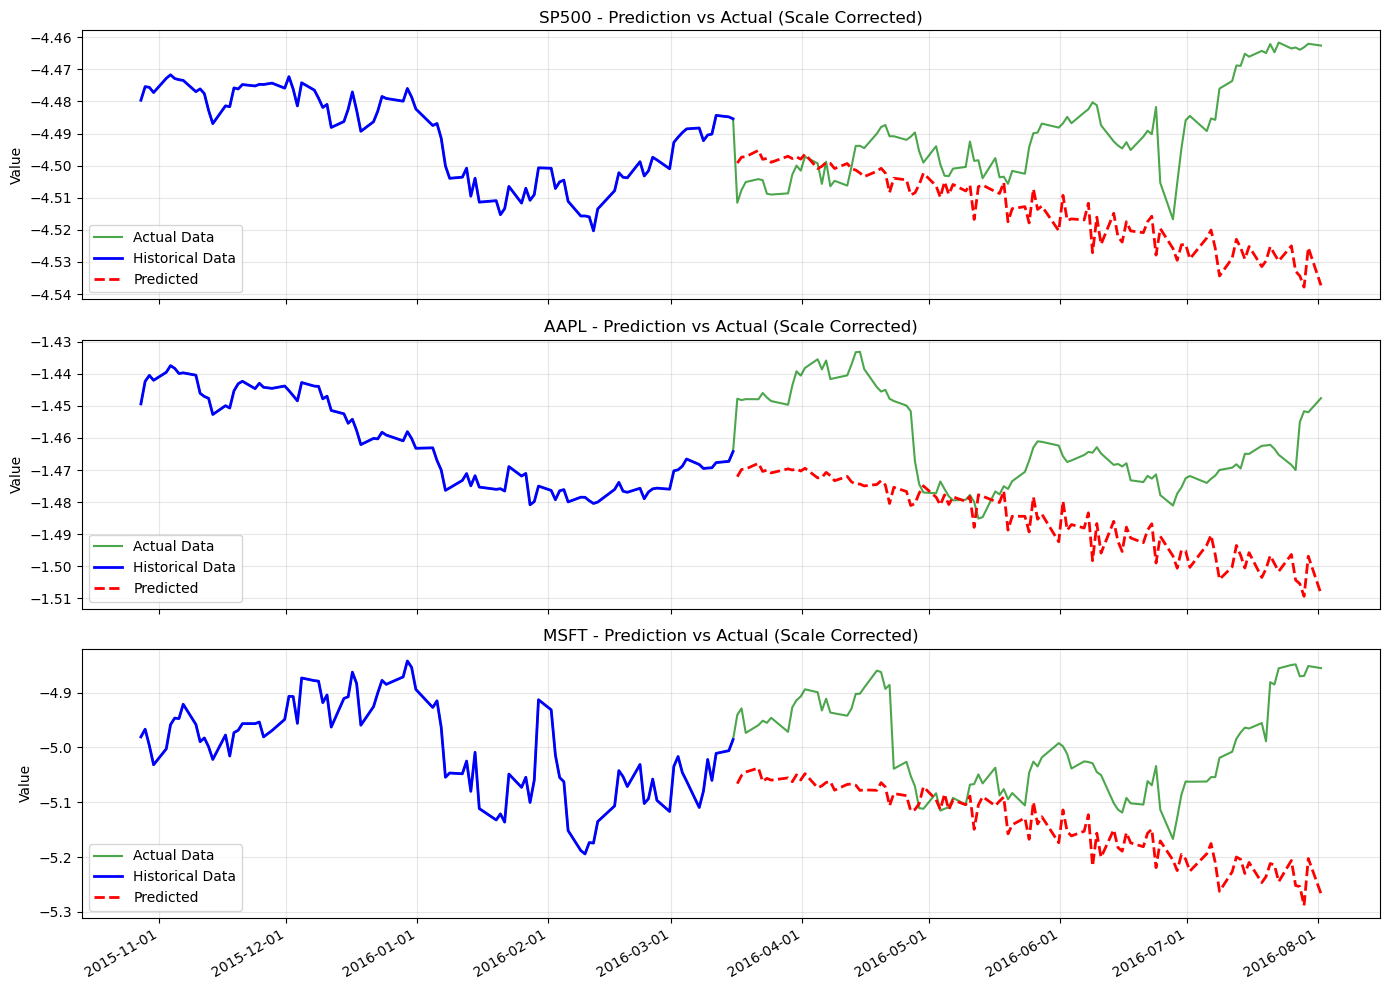

In [32]:
# Visualize model predictions with both continuity and scale normalization fixes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_stock_predictions_fixed_complete(predictions, test_data, args, target_stocks=['SP500', 'AAPL', 'MSFT']):
    """
    Plot predictions vs actual values with:
    1. Proper continuity between historical and actual data
    2. Scale normalization to handle mismatches
    """
    try:
        print(f"Predictions shape: {predictions.shape}")
        print(f"Test data shape: {test_data.shape}")
        
        # Create a figure with subplots
        plt.figure(figsize=(14, 10))
        
        # Look for the target stocks in the dataset
        found_stocks = []
        for stock in target_stocks:
            if stock in test_data.columns:
                found_stocks.append(stock)
        
        # If none found, use the first available numeric columns
        if not found_stocks:
            print("None of the specified stocks were found in the dataset.")
            numeric_cols = test_data.select_dtypes(include=[np.number]).columns
            found_stocks = numeric_cols[:min(3, len(numeric_cols))].tolist()
            print(f"Using available columns instead: {found_stocks}")
        
        # For each stock, create a subplot
        for i, stock_name in enumerate(found_stocks):
            plt.subplot(len(found_stocks), 1, i+1)
            
            try:
                # Find the index of this stock in the data
                if 'Date' in test_data.columns:
                    feature_idx = list(test_data.columns).index(stock_name) - 1  # -1 for Date column
                else:
                    feature_idx = list(test_data.columns).index(stock_name)
                
                # Extract a single sample for plotting (first sample)
                sample_idx = 0
                seq_len = args.seq_len
                pred_len = args.pred_len
                
                # Debug info
                print(f"\n{stock_name} data windows:")
                print(f"Sample index: {sample_idx}")
                print(f"Historical window: {sample_idx} to {sample_idx+seq_len-1}")
                print(f"Future window: {sample_idx+seq_len} to {sample_idx+seq_len+pred_len-1}")
                
                # Verify we have enough data
                if sample_idx + seq_len + pred_len <= len(test_data):
                    # Get x-axis values (dates or indices) ENSURING CONTINUITY
                    if 'Date' in test_data.columns:
                        all_dates = pd.to_datetime(test_data['Date'].iloc[sample_idx:sample_idx+seq_len+pred_len])
                        x_hist = all_dates[:seq_len]
                        x_future = all_dates[seq_len:]
                        
                        # Debug: verify these windows are adjacent
                        print(f"Last historical date: {x_hist.iloc[-1]}")
                        print(f"First future date: {x_future.iloc[0]}")
                    else:
                        all_indices = np.arange(sample_idx, sample_idx+seq_len+pred_len)
                        x_hist = all_indices[:seq_len]
                        x_future = all_indices[seq_len:]
                    
                    # Get values from a CONTINUOUS window of data
                    all_values = test_data[stock_name].iloc[sample_idx:sample_idx+seq_len+pred_len].values
                    y_hist = all_values[:seq_len]
                    y_actual = all_values[seq_len:]
                    
                    # Debug: print the last historical and first actual values to confirm continuity
                    print(f"Last historical value: {y_hist[-1]}")
                    print(f"First actual value: {y_actual[0]}")
                    
                    # Get predictions
                    if sample_idx < predictions.shape[0] and feature_idx < predictions.shape[2]:
                        y_pred = predictions[sample_idx, :pred_len, feature_idx]
                        
                        # Debug: print the first predicted value
                        print(f"First predicted value: {y_pred[0]}")
                        
                        # SCALE MISMATCH CHECK
                        hist_mean = np.mean(y_hist)
                        hist_std = np.std(y_hist)
                        pred_mean = np.mean(y_pred)
                        pred_std = np.std(y_pred)
                        actual_mean = np.mean(y_actual)
                        actual_std = np.std(y_actual)
                        
                        print(f"{stock_name} Statistics:")
                        print(f"Historical: mean={hist_mean:.4f}, std={hist_std:.4f}, range=[{np.min(y_hist):.4f}, {np.max(y_hist):.4f}]")
                        print(f"Predicted : mean={pred_mean:.4f}, std={pred_std:.4f}, range=[{np.min(y_pred):.4f}, {np.max(y_pred):.4f}]")
                        print(f"Actual    : mean={actual_mean:.4f}, std={actual_std:.4f}, range=[{np.min(y_actual):.4f}, {np.max(y_actual):.4f}]")
                        
                        # Check for scale mismatch and flat predictions
                        scale_mismatch = abs(actual_mean - hist_mean) > 0.5 or actual_std / max(hist_std, 1e-10) > 2
                        flat_prediction = pred_std < hist_std * 0.1
                        
                        if scale_mismatch or flat_prediction:
                            if scale_mismatch:
                                print(f"⚠️ Scale mismatch detected for {stock_name}.")
                            if flat_prediction:
                                print(f"⚠️ Predictions for {stock_name} show very little variation.")
                            
                            # Create a separate figure for detailed analysis
                            plt.figure(figsize=(16, 15))
                            
                            # 1. Original data plot
                            plt.subplot(3, 1, 1)
                            plt.plot(x_hist, y_hist, 'b-', label='Historical')
                            plt.plot(x_future, y_actual, 'g-', label='Actual Future')
                            plt.plot(x_future, y_pred, 'r--', label='Predicted')
                            plt.title(f'{stock_name} - Original Data')
                            plt.ylabel('Value')
                            plt.grid(True, alpha=0.3)
                            plt.legend()
                            
                            # 2. Scale-corrected plot (normalize actual to match historical/predicted)
                            plt.subplot(3, 1, 2)
                            # Normalize actual to match historical scale
                            y_actual_fixed = (y_actual - actual_mean) / max(actual_std, 1e-10) * max(hist_std, 1e-10) + hist_mean
                            
                            plt.plot(x_hist, y_hist, 'b-', label='Historical')
                            plt.plot(x_future, y_actual_fixed, 'g-', label='Actual Future (Rescaled)')
                            plt.plot(x_future, y_pred, 'r--', label='Predicted')
                            plt.title(f'{stock_name} - Actual Rescaled to Match Historical Scale')
                            plt.ylabel('Value (Normalized)')
                            plt.grid(True, alpha=0.3)
                            plt.legend()
                            
                            # 3. Alternative scale correction (normalize historical/predicted to match actual)
                            plt.subplot(3, 1, 3)
                            # Normalize historical and predictions to match actual scale
                            y_hist_fixed = (y_hist - hist_mean) / max(hist_std, 1e-10) * max(actual_std, 1e-10) + actual_mean
                            y_pred_fixed = (y_pred - pred_mean) / max(pred_std, 1e-10) * max(actual_std, 1e-10) + actual_mean
                            
                            plt.plot(x_hist, y_hist_fixed, 'b-', label='Historical (Rescaled)')
                            plt.plot(x_future, y_actual, 'g-', label='Actual Future')
                            plt.plot(x_future, y_pred_fixed, 'r--', label='Predicted (Rescaled)')
                            plt.title(f'{stock_name} - Historical/Predicted Rescaled to Match Actual Scale')
                            plt.ylabel('Value (Normalized to Actual)')
                            plt.grid(True, alpha=0.3)
                            plt.legend()
                            
                            # Format dates if available
                            if 'Date' in test_data.columns:
                                for ax in plt.gcf().get_axes():
                                    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
                                plt.gcf().autofmt_xdate()
                            
                            plt.tight_layout()
                            plt.savefig(f'predictions_{stock_name}_scale_analysis.png')
                            plt.close()
                            
                            # Use the corrected values for main plot (Option 1 by default)
                            # Uncomment the second option if you believe actual values are correct
                            
                            # Option 1: Modify actual to match historical/predicted scale
                            y_actual = y_actual_fixed
                            
                            # Option 2: Modify historical/predicted to match actual scale
                            # y_hist = y_hist_fixed
                            # y_pred = y_pred_fixed
                        
                        # MAIN PLOT: Plot a continuous line with corrected scaling
                        
                        # First create a combined continuous data array
                        combined_x = np.concatenate([x_hist, x_future])
                        combined_actual = np.concatenate([y_hist, y_actual])  # Now uses corrected y_actual if needed
                        
                        # Plot the full actual data as a continuous line
                        plt.plot(combined_x, combined_actual, 'g-', label='Actual Data', alpha=0.7)
                        
                        # Highlight historical portion
                        plt.plot(x_hist, y_hist, 'b-', label='Historical Data', linewidth=2)
                        
                        # Add predictions
                        plt.plot(x_future, y_pred, 'r--', label='Predicted', linewidth=2)
                        
                        plt.title(f'{stock_name} - Prediction vs Actual (Scale Corrected)')
                        plt.ylabel('Value')
                        plt.grid(True, alpha=0.3)
                        
                        # Format dates if available
                        if 'Date' in test_data.columns:
                            plt.gcf().autofmt_xdate()
                            plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
                        
                        plt.legend()
                    else:
                        plt.text(0.5, 0.5, f'Index error: prediction shape is {predictions.shape}',
                                ha='center', va='center')
                else:
                    plt.text(0.5, 0.5, 'Not enough data for this sample',
                            ha='center', va='center')
            except Exception as e:
                plt.text(0.5, 0.5, f'Error plotting {stock_name}: {str(e)}',
                        ha='center', va='center')
                print(f"Error plotting {stock_name}: {e}")
        
        plt.tight_layout()
        plt.savefig(f'predictions_key_stocks_fixed.png')
        plt.show()
        
    except Exception as e:
        print(f"Error creating plots: {e}")
        plt.figure(figsize=(10, 6))
        plt.text(0.5, 0.5, f'Error creating prediction plots:\n{str(e)}',
                ha='center', va='center', fontsize=12)
        plt.tight_layout()
        plt.savefig('predictions_error.png')
        plt.show()

# Call the function
setting = f'{args.data}_{args.model}_{args.seq_len}_{args.pred_len}'
plot_stock_predictions_fixed_complete(predictions, test_data, args)

In [ ]:
# Visualize model predictions with proper scaling and continuity
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get the original data and dates
original_data = pd.read_csv(os.path.join(args.root_path, args.data_path))
dates = pd.to_datetime(original_data['Date'])

# Specific stocks to plot
target_stocks = ['SP500', 'AAPL', 'MSFT']

# Find column indices for the target stocks
stock_indices = [list(original_data.columns).index(stock) - 1 for stock in target_stocks]  # -1 to adjust for Date column

# Create a figure with subplots for each stock
plt.figure(figsize=(15, 12))

for i, (stock, idx) in enumerate(zip(target_stocks, stock_indices)):
    ax = plt.subplot(3, 1, i+1)
    
    # Get the test period data for plotting
    test_start_idx = val_end - args.seq_len
    test_dates = dates[val_end:].reset_index(drop=True)
    
    # Get historical data for context (used for model input)
    historical_dates = dates[test_start_idx:val_end].reset_index(drop=True)
    historical_values = test_data_no_date.iloc[:args.seq_len, idx+1].values if 'Date' in test_data_no_date.columns else test_data_no_date.iloc[:args.seq_len, idx].values
    
    # Get actual future values
    actual_values = original_data.iloc[val_end:, idx+1].values if 'Date' in original_data.columns else original_data.iloc[val_end:, idx].values
    
    # Extract predictions for this specific stock
    stock_predictions = predictions[:, :, idx]
    
    # Inverse transform if data was scaled
    if 'Date' in train_data.columns:
        # Get the original scale for this stock
        scaler_mean = scaler.mean_[idx]
        scaler_scale = scaler.scale_[idx]
        
        # Inverse transform the historical values and predictions
        historical_values = historical_values * scaler_scale + scaler_mean
        stock_predictions = stock_predictions * scaler_scale + scaler_mean
    
    # Plot historical data
    ax.plot(historical_dates, historical_values, 'b-', label=f'Historical {stock}')
    
    # Plot actual future values
    ax.plot(test_dates, actual_values, 'g-', label=f'Actual {stock}')
    
    # Plot predictions for each prediction window
    for j in range(min(5, len(stock_predictions))):  # Limit to first 5 predictions to avoid clutter
        pred_dates = test_dates[j:j+args.pred_len]
        if len(pred_dates) == len(stock_predictions[j]):
            ax.plot(pred_dates, stock_predictions[j], 'r--', alpha=0.5)
    
    # Plot the first prediction more prominently
    ax.plot(test_dates[:args.pred_len], stock_predictions[0], 'r-', label=f'Predicted {stock}')
    
    ax.set_title(f'{stock} Price Prediction')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()